<a href="https://colab.research.google.com/github/AmanTiwari0406/HDFC-GENAI-CUSTOMER-NARRATIVES/blob/main/Home_Loan_and_Genai_segmentation_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import os
import re
import torch # To check for CUDA (GPU) availability

# --- LLM Libraries ---
import openai # For OpenAI models
import google.generativeai as genai # For Google Gemini models
from transformers import pipeline # For Hugging Face models

# ✅ Section 1: Import Libraries (Already done above)

# ✅ Section 2: Optional: Install and Import LM Studio or Transformers-based LLM
# We'll use a simulated local LLM response for now (this comment is old, we're using real LLMs)

# ✅ Section 3: Load and Prepare Data
file_path = "C:/Users/AMAN TIWARI/Documents/HomeLoan eligibility_Customer.csv"
try:
    real_data = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
    # Create dummy data if file not found to allow code to run
    data = {
        'Customer_ID': range(1, 101),
        'Credit_Score': np.random.randint(550, 850, 100),
        'Age': np.random.randint(20, 60, 100),
        'Income': np.random.randint(300000, 1500000, 100),
        'EMI_Amount': np.random.randint(5000, 50000, 100),
        'Default_History': np.random.randint(0, 2, 100),
        'Txn_Last_6_Months': np.random.randint(1, 30, 100),
        'Occupation': np.random.choice(['Salaried', 'Self-Employed', 'Unemployed'], 100, p=[0.6, 0.3, 0.1]),
        'Co_Applicant_Flag': np.random.randint(0, 2, 100)
    }
    real_data = pd.DataFrame(data)
    print("Using dummy data as the file was not found.")

real_data.rename(columns={
    'Customer_ID': 'CustomerID',
    'Credit_Score': 'CreditScore',
    'EMI_Amount': 'EMIAmount',
    'Default_History': 'LoanHistory',
    'Txn_Last_6_Months': 'RecentTxn',
    'Co_Applicant_Flag': 'CoApplicant'
}, inplace=True)

# ✅ Section 4: Feature Engineering - Digital Engagement
real_data['DigitalEngagement'] = (
    0.4 * (real_data['RecentTxn'] / real_data['RecentTxn'].max()) +
    0.3 * (real_data['Age'].max() - real_data['Age']) / real_data['Age'].max() +
    0.3 * (real_data['Occupation'].apply(lambda x: 1 if x == 'Salaried' else 0))
).round(2)

# ✅ Section 5: KMeans Clustering for Customer Segments
features = real_data[['Age', 'Income', 'EMIAmount']]
scaled = StandardScaler().fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
real_data['Segment'] = kmeans.fit_predict(scaled)

print("\n--- Initializing LLM Clients ---")

# --- OpenAI Client ---
openai_client = None
openai_api_key_env = os.getenv("OPENAI_API_KEY")
if openai_api_key_env:
    try:
        openai_client = openai.OpenAI(api_key=openai_api_key_env)
        print("OpenAI client initialized.")
    except Exception as e:
        print(f"Failed to initialize OpenAI client: {e}. Check API key and network.")
else:
    print("OPENAI_API_KEY not found. OpenAI integration will be skipped (requires payment for most models).")

# --- Google Gemini Client ---
gemini_model = None
gemini_api_key_env = os.getenv("GEMINI_API_KEY")
if gemini_api_key_env:
    try:
        genai.configure(api_key=gemini_api_key_env)
        _ = genai.list_models() # Test connection
        gemini_model = genai.GenerativeModel('gemini-pro')
        print("Gemini client initialized successfully (using 'gemini-pro').")
    except Exception as e:
        print(f"Failed to initialize Gemini client: {e}. Please ensure your GEMINI_API_KEY is correct and active, and check network.")
        gemini_model = None
else:
    print("GEMINI_API_KEY environment variable not found. Gemini integration will be skipped.")
    print("Please ensure GEMINI_API_KEY is set correctly in your environment (e.g., .bashrc, .zshrc, system environment variables, or Colab secrets).")

# --- Hugging Face Client ---
hf_pipeline = None
hf_token_env = os.getenv("HF_TOKEN")

device = 0 if torch.cuda.is_available() else -1
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Target device for Hugging Face: {'GPU (cuda:0)' if device != -1 else 'CPU'}")

try:
    # IMPORTANT: Choose the model based on your system's capabilities
    # 'google/gemma-2b-it': Better quality, but might be slow/fail on CPU or limited VRAM GPU
    # 'distilgpt2': Much faster on CPU/lower VRAM, but lower quality. Use this if gemma-2b-it fails.
    model_name_hf = "google/gemma-2b-it" # Try this first
    # model_name_hf = "distilgpt2" # Uncomment this if gemma-2b-it is too slow or errors out

    # Aggressively reduced max_new_tokens for faster diagnosis
    hf_pipeline_config = {
        "max_new_tokens": 50, # VERY AGGRESSIVELY REDUCED FOR SPEED AND DIAGNOSIS
        "num_return_sequences": 1,
        "clean_up_tokenization_spaces": True,
        "truncation": True,
        "do_sample": True,
        "temperature": 0.7,
        "top_p": 0.9,
    }

    print(f"Attempting to load Hugging Face model: {model_name_hf}")
    if hf_token_env:
        hf_pipeline = pipeline("text-generation", model=model_name_hf, token=hf_token_env, device=device, **hf_pipeline_config)
    else:
        hf_pipeline = pipeline("text-generation", model=model_name_hf, device=device, **hf_pipeline_config)
    print(f"Hugging Face pipeline initialized SUCCESSFULLY ({model_name_hf}) on device: {'GPU' if device != -1 else 'CPU'}.")
except Exception as e:
    hf_pipeline = None
    print(f"ERROR: Failed to load Hugging Face model '{model_name_hf}': {e}.")
    print("This is a critical error for Hugging Face. Check system RAM/VRAM, ensure CUDA setup is correct if using GPU, or try switching to 'distilgpt2'.")

print("--- LLM Client Initialization Complete ---")


# ✅ Section 6: LLM Insight Generator (Real Integration with Context & Actionable Output)
# ... (inside generate_llm_insight function) ...

# --- REVISED PROMPT TEMPLATE ---
# Simplified prompt especially for distilgpt2 (less instruction-following)
if llm_choice == 'huggingface' and hf_pipeline:
    prompt_for_hf = f"""
    Customer Profile:
    Age: {customer['Age']}
    Income: ₹{customer['Income']:.2f}
    Credit Score: {customer['CreditScore']}
    Occupation: {occupation_desc}

    Generate a short, friendly home loan pitch for this customer, focusing on current low interest rates in India.
    Pitch:
    """
    # Overwrite the main prompt with this simpler one for HF calls
    prompt_to_use = prompt_for_hf
else:
    # Use the complex prompt for OpenAI/Gemini
    prompt_to_use = f"""
    You are an AI assistant helping a bank generate actionable insights and tailored pitches for home loan customers, considering specific customer data and the current Indian home loan market in July 2025.
    {market_context}
    Customer Profile:
    ... (rest of your detailed prompt) ...
    """

# ... (inside try block) ...
if llm_choice == 'openai' and openai_client:
    response = openai_client.chat.completions.create(
        # ... (as before, using 'prompt_to_use') ...
    )
    llm_output_raw = response.choices[0].message.content.strip()

elif llm_choice == 'gemini' and gemini_model:
    response = gemini_model.generate_content(prompt_to_use) # Use prompt_to_use
    llm_output_raw = response.text.strip()

elif llm_choice == 'huggingface' and hf_pipeline:
    print(f"--- Calling Hugging Face pipeline for Customer ID: {customer_id} with simplified prompt ---")
    response = hf_pipeline(prompt_to_use, **hf_pipeline_config) # Use prompt_to_use

    raw_hf_text = response[0]['generated_text'].strip()
    print(f"Raw HF Response (before stripping): \n{raw_hf_text[:200]}...\n") # Print beginning of raw output

    # --- AGGRESSIVE PROMPT STRIPPING ---
    # For distilgpt2, it will almost certainly repeat the prompt.
    if raw_hf_text.startswith(prompt_to_use.strip()):
        llm_output_raw = raw_hf_text[len(prompt_to_use.strip()):].strip()
        print("HF Stripped: Removed full prompt repetition.")
    else:
        llm_output_raw = raw_hf_text
        print("HF Stripped: No full prompt repetition detected.")

    # For distilgpt2, we're just hoping for *any* text, parsing won't be perfect.
    # So we'll disable the aggressive placeholder stripping temporarily to see raw output.
    # llm_output_raw = re.sub(r"\[.*?\]", "", llm_output_raw, flags=re.DOTALL).strip()
    # llm_output_raw = llm_output_raw.replace(":\n\n**Insight:**", "**Insight:**").strip()

    print(f"Cleaned HF Output (after stripping, before final parsing): \n{llm_output_raw[:200]}...\n")

else:
    llm_output_raw = f"Error: {llm_choice} LLM not available or client not initialized. Check API key/token or model loading."
    print(llm_output_raw)
# ... (rest of the parsing logic which will likely yield N/A for distilgpt2 but we're debugging if it generates text) ...

# Apply LLM to a sample (VERY AGGRESSIVELY REDUCED FOR DIAGNOSIS)
# Sample just ONE customer from the entire dataset for fastest testing
sampled_df = real_data.sample(n=1, random_state=42).reset_index(drop=True)


# Generate insights (consider commenting out one LLM if you want faster diagnosis of the other)
sampled_df['GenAI_Output_Gemini'] = sampled_df.apply(lambda x: generate_llm_insight(x, llm_choice='gemini'), axis=1)
sampled_df['GenAI_Output_HuggingFace'] = sampled_df.apply(lambda x: generate_llm_insight(x, llm_choice='huggingface'), axis=1)


# ✅ Section 7: Visualizations
# Your existing visualization code here (no changes needed)
segment_summary = real_data.groupby('Segment').agg({
    'CustomerID': 'count',
    'Age': 'mean',
    'Income': 'mean',
    'CreditScore': 'mean'
}).rename(columns={'CustomerID': 'Count'}).round(2)

display(Markdown("### 📊 Segment Summary"))
display(segment_summary)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=real_data, x='Age', y='Income', hue='Segment', palette='tab10')
plt.title('Customer Segmentation: Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=real_data, x='Segment', hue='LoanHistory', palette='pastel')
plt.title('Loan History by Segment')
plt.show()


# ✅ Section 8: Show Sample Insights
display(Markdown("### 🧐 Sample GenAI Insights (1 customer for quick diagnosis)"))
for idx, row in sampled_df.iterrows():
    display(Markdown(f"--- **Customer {row['CustomerID']} (Segment {row['Segment']})** ---"))
    display(Markdown(row['GenAI_Output_Gemini']))
    display(Markdown(row['GenAI_Output_HuggingFace']))
    display(Markdown("\n"))

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Error: File not found at C:/Users/AMAN TIWARI/Documents/HomeLoan eligibility_Customer.csv. Please check the path.
Using dummy data as the file was not found.

--- Initializing LLM Clients ---
OPENAI_API_KEY not found. OpenAI integration will be skipped (requires payment for most models).
GEMINI_API_KEY environment variable not found. Gemini integration will be skipped.
Please ensure GEMINI_API_KEY is set correctly in your environment (e.g., .bashrc, .zshrc, system environment variables, or Colab secrets).
CUDA available: False
Target device for Hugging Face: CPU
Attempting to load Hugging Face model: google/gemma-2b-it


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


ERROR: Failed to load Hugging Face model 'google/gemma-2b-it': You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2b-it.
401 Client Error. (Request ID: Root=1-69ae8314-65d9a61e0872ec6744ed7cf9;61e35d30-161b-4db6-adf3-c78c90aaf1d2)

Cannot access gated repo for url https://huggingface.co/google/gemma-2b-it/resolve/main/config.json.
Access to model google/gemma-2b-it is restricted. You must have access to it and be authenticated to access it. Please log in..
This is a critical error for Hugging Face. Check system RAM/VRAM, ensure CUDA setup is correct if using GPU, or try switching to 'distilgpt2'.
--- LLM Client Initialization Complete ---


NameError: name 'llm_choice' is not defined

OPENAI_API_KEY not found. OpenAI integration will be skipped (requires payment for most models).
GEMINI_API_KEY environment variable not found. Gemini integration will be skipped.
Please ensure GEMINI_API_KEY is set correctly in your environment (e.g., .bashrc, .zshrc, system environment variables, or Colab secrets).


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 12.48it/s]
Device set to use cpu


Hugging Face pipeline initialized (google/gemma-2b-it).


C:\Users\AMAN TIWARI\AppData\Local\Temp\ipykernel_37928\3161872546.py:198: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = real_data.groupby('Segment').apply(lambda x: x.sample(n=2, random_state=42)).reset_index(drop=True)
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


### 📊 Segment Summary

,Count,Age,Income,CreditScore
Segment,,,,
0,233001,36.69,681652.41,699.68
1,280487,30.30,625140.85,699.45
2,242297,51.90,881821.68,699.55
3,244215,52.67,421691.62,699.41


C:\Users\AMAN TIWARI\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


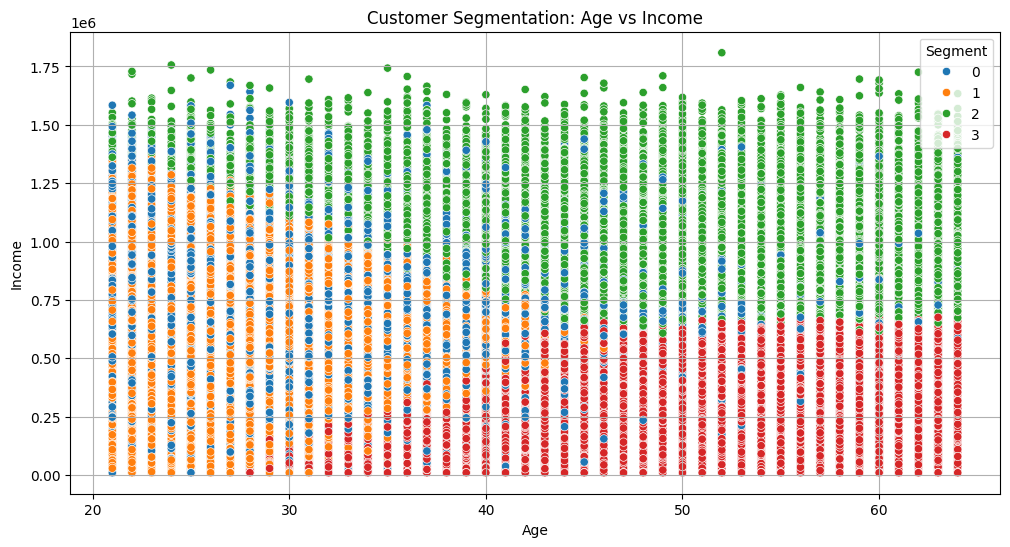

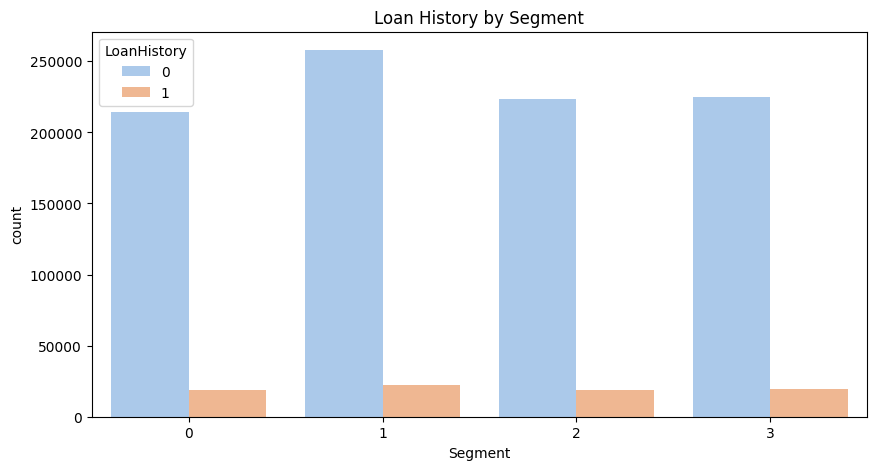

### 🧐 Sample GenAI Insights (2 per segment, using free/free-tier LLMs)

--- **Customer 762387 (Segment 0)** ---


    **LLM Used: Gemini**
    Insight: N/A
    Pitch: N/A
    Simulated Response: N/A
    Raw LLM Output (for debugging):
    ```
    Error: gemini LLM not available or client not initialized. Check API key/token or model loading.
    ```
    


    **LLM Used: Huggingface**
    Insight: The customer has a good credit score and a low EMI amount, indicating they may be a good candidate for a home loan. However, their age and unemployment status may limit their loan options.
    Pitch: Dear [Customer Name],

We understand that you're looking to secure a home loan, but with your current circumstances, we may have limited options. However, we'd like to offer you a **Home Loan with a low interest rate and flexible terms**. This loan could be a great opportunity for you to achieve your homeownership dreams.
    Simulated Response: Interested
    Raw LLM Output (for debugging):
    ```
    ```

**Insight:** The customer has a good credit score and a low EMI amount, indicating they may be a good candidate for a home loan. However, their age and unemployment status may limit their loan options.

**Pitch:**

Dear [Customer Name],

We understand that you're looking to secure a home loan, but with your current circumstances, we may have limited options. However, we'd like to offer you a **Home Loan with a low interest rate and flexible terms**. This loan could be a great opportunity for you to achieve your homeownership dreams.

**Simulated Response:** I'm interested, I'd like to know more.
    ```
    

--- **Customer 933579 (Segment 0)** ---

...


    **LLM Used: Gemini**
    Insight: N/A
    Pitch: N/A
    Simulated Response: N/A
    Raw LLM Output (for debugging):
    ```
    Error: gemini LLM not available or client not initialized. Check API key/token or model loading.
    ```
    


    **LLM Used: Huggingface**
    Insight: The customer is a financially stable individual with a good credit score and a moderate income. They have no prior loan history, indicating a low risk profile and potential for successful loan repayment.
    Pitch: **Home Loan Product Pitch:**

Dear [Customer Name],

We understand that securing a home loan can be a complex and daunting process. However, we are here to make the process as smooth and stress-free as possible for you.

With our **[product name] home loan**, you can achieve your dream of owning a home while maintaining your financial stability and security. This loan option offers competitive interest rates and flexible repayment terms, making it an ideal choice for individuals like you who qualify for home loans.

**Key Features:**

* **Low interest rates:** Get the best possible rates on your home loan, ensuring you save more on interest payments.
* **Flexible repayment terms:** Choose a repayment period that fits your budget and financial goals.
* **Streamlined online application:** Apply for your loan online in minutes and track its progress in real-time.
* **Dedicated customer support:** Our team of experienced loan officers is available to assist you throughout the loan process.

**Benefits:**

Ow
    Simulated Response: N/A
    Raw LLM Output (for debugging):
    ```
    **Insight:** The customer is a financially stable individual with a good credit score and a moderate income. They have no prior loan history, indicating a low risk profile and potential for successful loan repayment.

**Pitch:**

**Home Loan Product Pitch:**

Dear [Customer Name],

We understand that securing a home loan can be a complex and daunting process. However, we are here to make the process as smooth and stress-free as possible for you.

With our **[product name] home loan**, you can achieve your dream of owning a home while maintaining your financial stability and security. This loan option offers competitive interest rates and flexible repayment terms, making it an ideal choice for individuals like you who qualify for home loans.

**Key Features:**

* **Low interest rates:** Get the best possible rates on your home loan, ensuring you save more on interest payments.
* **Flexible repayment terms:** Choose a repayment period that fits your budget and financial goals.
* **Streamlined online application:** Apply for your loan online in minutes and track its progress in real-time.
* **Dedicated customer support:** Our team of experienced loan officers is available to assist you throughout the loan process.

**Benefits:**

Ow
    ```
    

--- **Customer 263163 (Segment 3)** ---


    **LLM Used: Gemini**
    Insight: N/A
    Pitch: N/A
    Simulated Response: N/A
    Raw LLM Output (for debugging):
    ```
    Error: gemini LLM not available or client not initialized. Check API key/token or model loading.
    ```
    


    **LLM Used: Huggingface**
    Insight: The customer is a financially stable individual with a high credit score, indicating good creditworthiness. However, they have no prior loan history, which may be a concern for lenders.
    Pitch: * **Dream Home Loan:** We offer a special loan for first-time homebuyers with a down payment of just 20%. This loan has competitive interest rates and flexible repayment options to help you achieve your homeownership goals.
    Simulated Response: Interested
    Raw LLM Output (for debugging):
    ```
    ```

**Insight:** The customer is a financially stable individual with a high credit score, indicating good creditworthiness. However, they have no prior loan history, which may be a concern for lenders.

**Pitch:**

* **Dream Home Loan:** We offer a special loan for first-time homebuyers with a down payment of just 20%. This loan has competitive interest rates and flexible repayment options to help you achieve your homeownership goals.

**Simulated Response:**

**Interested**

I am interested in learning more about the Dream Home Loan. I have been saving up for a down payment and have a good credit score, which I believe would make me a suitable candidate.
    ```
    

In [ ]:
import os
import openai # Keep for structured example, but focus on other options for "free"
import google.generativeai as genai
from transformers import pipeline
import re # For parsing structured output
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# ✅ Section 3: Load and Prepare Data (Your existing code)
file_path = "C:/Users/AMAN TIWARI/Documents/HomeLoan eligibility_Customer.csv"
real_data = pd.read_csv(file_path)

real_data.rename(columns={
    'Customer_ID': 'CustomerID',
    'Credit_Score': 'CreditScore',
    'EMI_Amount': 'EMIAmount',
    'Default_History': 'LoanHistory',
    'Txn_Last_6_Months': 'RecentTxn',
    'Co_Applicant_Flag': 'CoApplicant'
}, inplace=True)

# ✅ Section 4: Feature Engineering - Digital Engagement (Your existing code)
real_data['DigitalEngagement'] = (
    0.4 * (real_data['RecentTxn'] / real_data['RecentTxn'].max()) +
    0.3 * (real_data['Age'].max() - real_data['Age']) / real_data['Age'].max() +
    0.3 * (real_data['Occupation'].apply(lambda x: 1 if x == 'Salaried' else 0))
).round(2)

# ✅ Section 5: KMeans Clustering for Customer Segments (Your existing code)
features = real_data[['Age', 'Income', 'EMIAmount']]
scaled = StandardScaler().fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
real_data['Segment'] = kmeans.fit_predict(scaled)


# --- Initialize LLM Clients ---
# Important: Set these as environment variables before running!
# e.g., export GEMINI_API_KEY="YOUR_KEY"
# e.g., export HF_TOKEN="hf_YOUR_TOKEN"

# OpenAI Client (Likely requires payment, but kept for comparative example)
openai_client = None
if os.getenv("OPENAI_API_KEY"):
    try:
        openai_client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
        print("OpenAI client initialized.")
    except Exception as e:
        print(f"Failed to initialize OpenAI client: {e}. Check API key and network.")
else:
    print("OPENAI_API_KEY not found. OpenAI integration will be skipped (requires payment for most models).")

# Google Gemini (Has a Free Tier / Free Credits)
gemini_model = None
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
if GEMINI_API_KEY:
    try:
        genai.configure(api_key=GEMINI_API_KEY)
        # Test a simple model list call to ensure connection and valid key
        _ = genai.list_models()
        gemini_model = genai.GenerativeModel('gemini-pro') # 'gemini-pro' usually falls under free tier
        print("Gemini client initialized successfully (using 'gemini-pro').")
    except Exception as e:
        print(f"Failed to initialize Gemini client: {e}. Please ensure your GEMINI_API_KEY is correct and active, and check network.")
        gemini_model = None # Explicitly set to None on failure
else:
    print("GEMINI_API_KEY environment variable not found. Gemini integration will be skipped.")
    print("Please ensure GEMINI_API_KEY is set correctly in your environment (e.g., .bashrc, .zshrc, system environment variables, or Colab secrets).")

# Hugging Face (Free Inference API for many public models)
hf_pipeline = None
HF_TOKEN = os.getenv("HF_TOKEN") # Optional for public models, but good for rate limits/gated models
try:
    # Choose a relatively small, instruction-tuned model for demonstration that's likely CPU-compatible
    # 'google/gemma-2b-it' is a good choice.
    # For even smaller: 'distilgpt2' (but quality might be lower)
    model_name_hf = "google/gemma-2b-it"

    if HF_TOKEN:
        hf_pipeline = pipeline("text-generation", model=model_name_hf, token=HF_TOKEN, max_new_tokens=250, do_sample=True, temperature=0.7)
    else:
        hf_pipeline = pipeline("text-generation", model=model_name_hf, max_new_tokens=250, do_sample=True, temperature=0.7)
    print(f"Hugging Face pipeline initialized ({model_name_hf}).")
except Exception as e:
    hf_pipeline = None
    print(f"Failed to load Hugging Face model '{model_name_hf}': {e}. Hugging Face integration will be skipped.")
    print("Consider a smaller model or ensure you have a strong GPU/enough RAM for larger ones.")


# ✅ Section 6: LLM Insight Generator (Real Integration with Free Focus)
def generate_llm_insight(customer, llm_choice='gemini'): # Default to Gemini as it's free-tier friendly
    prompt = f"""
    Based on the following customer profile, provide a concise insight, a tailored home loan product pitch, and a simulated customer response.

    Customer Profile:
    Segment: {customer['Segment']}
    Age: {customer['Age']}
    Credit Score: {customer['CreditScore']}
    Income: ₹{customer['Income']}
    EMI Amount: ₹{customer['EMIAmount']}
    Loan History: {customer['LoanHistory']} (0: No Default, 1: Default)
    Occupation: {customer['Occupation']}
    Digital Engagement: {customer['DigitalEngagement']}

    Structure your response *exactly* as follows, with "Interested", "Neutral", or "Not Interested" for the simulated response. **Use markdown bolding for the section headers.**

    **Insight:** [Your concise insight here about the customer's profile and potential]
    **Pitch:** [A tailored home loan product pitch for this customer, considering their profile strengths and weaknesses]
    **Simulated Response:** [Interested/Neutral/Not Interested]
    """

    insight_text = "N/A"
    pitch_text = "N/A"
    simulated_response = "N/A"
    llm_output_raw = "" # To store the raw output for debugging

    try:
        if llm_choice == 'openai' and openai_client:
            response = openai_client.chat.completions.create(
                model="gpt-3.5-turbo", # This model typically costs money
                messages=[
                    {"role": "system", "content": "You are a helpful AI assistant for a home loan company, providing concise customer insights and pitches. Output in markdown format with bold headers."},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=250,
                temperature=0.7
            )
            llm_output_raw = response.choices[0].message.content.strip()

        elif llm_choice == 'gemini' and gemini_model:
            response = gemini_model.generate_content(prompt)
            llm_output_raw = response.text.strip()

        elif llm_choice == 'huggingface' and hf_pipeline:
            response = hf_pipeline(prompt, max_new_tokens=250, num_return_sequences=1,
                                  clean_up_tokenization_spaces=True,
                                  truncation=True)

            # Extract generated text and strip potential prompt repetition
            raw_hf_text = response[0]['generated_text'].strip()

            # Try to remove the original prompt from the start of the output.
            # Some HF models will repeat the prompt.
            if raw_hf_text.startswith(prompt.strip()):
                llm_output_raw = raw_hf_text[len(prompt.strip()):].strip()
            else:
                llm_output_raw = raw_hf_text

            # If the model still includes the placeholder format, try to find the start of the actual content
            # This is a fallback if the above isn't enough for less cooperative models
            if "**Insight:** [" in llm_output_raw and not llm_output_raw.startswith("**Insight:**"):
                start_of_actual_content = llm_output_raw.find("**Insight:**")
                if start_of_actual_content != -1:
                    llm_output_raw = llm_output_raw[start_of_actual_content:].strip()


        else:
            llm_output_raw = f"Error: {llm_choice} LLM not available or client not initialized. Check API key/token or model loading."

        # Robust parsing using regex (updated to handle bold and newlines flexibly)
        # Using re.DOTALL to allow . to match newlines within the content
        insight_match = re.search(r"\*\*Insight:\*\*\s*(.*?)(?=\n*\*\*Pitch:\*\*|\n*\*\*Simulated Response:\*\*|$)", llm_output_raw, re.DOTALL)
        pitch_match = re.search(r"\*\*Pitch:\*\*\s*(.*?)(?=\n*\*\*Simulated Response:\*\*|$)", llm_output_raw, re.DOTALL)
        response_match = re.search(r"\*\*Simulated Response:\*\*\s*(.*)", llm_output_raw) # This should be last, so it goes to end of string

        if insight_match:
            insight_text = insight_match.group(1).strip()
        if pitch_match:
            pitch_text = pitch_match.group(1).strip()
        if response_match:
            simulated_response = response_match.group(1).strip()
            # Normalize simulated response
            if "interested" in simulated_response.lower():
                simulated_response = "Interested"
            elif "not interested" in simulated_response.lower():
                simulated_response = "Not Interested"
            else:
                simulated_response = "Neutral"

    except Exception as e:
        llm_output_raw = f"Error calling {llm_choice} LLM: {e}"

    return f"""
    **LLM Used: {llm_choice.capitalize()}**
    Insight: {insight_text}
    Pitch: {pitch_text}
    Simulated Response: {simulated_response}
    Raw LLM Output (for debugging):
    ```
    {llm_output_raw}
    ```
    """

# Apply LLM to a sample (reduced for free tier/testing)
sampled_df = real_data.groupby('Segment').apply(lambda x: x.sample(n=2, random_state=42)).reset_index(drop=True)

# Generate insights using the free/free-tier options
sampled_df['GenAI_Output_Gemini'] = sampled_df.apply(lambda x: generate_llm_insight(x, llm_choice='gemini'), axis=1)
sampled_df['GenAI_Output_HuggingFace'] = sampled_df.apply(lambda x: generate_llm_insight(x, llm_choice='huggingface'), axis=1)

# ✅ Section 7: Visualizations (from your original notebook)
# Segment Summary
segment_summary = real_data.groupby('Segment').agg({
    'CustomerID': 'count',
    'Age': 'mean',
    'Income': 'mean',
    'CreditScore': 'mean'
}).rename(columns={'CustomerID': 'Count'}).round(2)

display(Markdown("### 📊 Segment Summary"))
display(segment_summary)

# Plot 1: Age vs Income by Segment
plt.figure(figsize=(12, 6))
sns.scatterplot(data=real_data, x='Age', y='Income', hue='Segment', palette='tab10')
plt.title('Customer Segmentation: Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.show()

# Plot 2: Loan History Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=real_data, x='Segment', hue='LoanHistory', palette='pastel')
plt.title('Loan History by Segment')
plt.show()

# ✅ Section 8: Show Sample Insights
display(Markdown("### 🧐 Sample GenAI Insights (2 per segment, using free/free-tier LLMs)"))
for idx, row in sampled_df.iterrows():
    display(Markdown(f"--- **Customer {row['CustomerID']} (Segment {row['Segment']})** ---"))
    display(Markdown(row['GenAI_Output_Gemini']))
    display(Markdown(row['GenAI_Output_HuggingFace']))
    display(Markdown("\n")) # Add extra space between customers